In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r'D:\twitter-sentiment-analyzer\data\training.1600000.processed.noemoticon.csv',
                 encoding='latin-1',
                 names=['target','id','date','flag','user','text'])

# Keep only what we need
df = df[['text', 'target']]

# Check the shape
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nSentiment counts:")
print(df['target'].value_counts())

Shape: (1600000, 2)

First 5 rows:
                                                text  target
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...       0
1  is upset that he can't update his Facebook by ...       0
2  @Kenichan I dived many times for the ball. Man...       0
3    my whole body feels itchy and like its on fire        0
4  @nationwideclass no, it's not behaving at all....       0

Sentiment counts:
target
0    800000
4    800000
Name: count, dtype: int64


In [2]:
# Convert target: 4 → 1 (positive), 0 stays 0 (negative)
df['target'] = df['target'].map({0: 0, 4: 1})

# Check tweet length distribution
df['length'] = df['text'].apply(len)

print("Average tweet length:", df['length'].mean().round(2))
print("Shortest tweet:", df['length'].min())
print("Longest tweet:", df['length'].max())
print("\nUpdated sentiment counts:")
print(df['target'].value_counts())

Average tweet length: 74.09
Shortest tweet: 6
Longest tweet: 374

Updated sentiment counts:
target
0    800000
1    800000
Name: count, dtype: int64


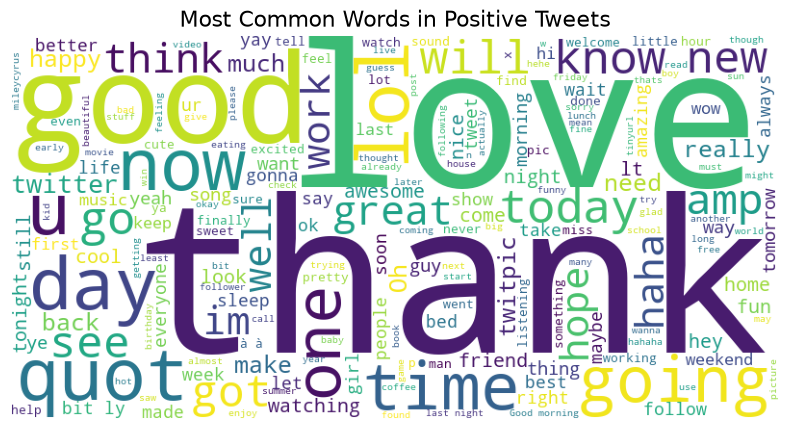

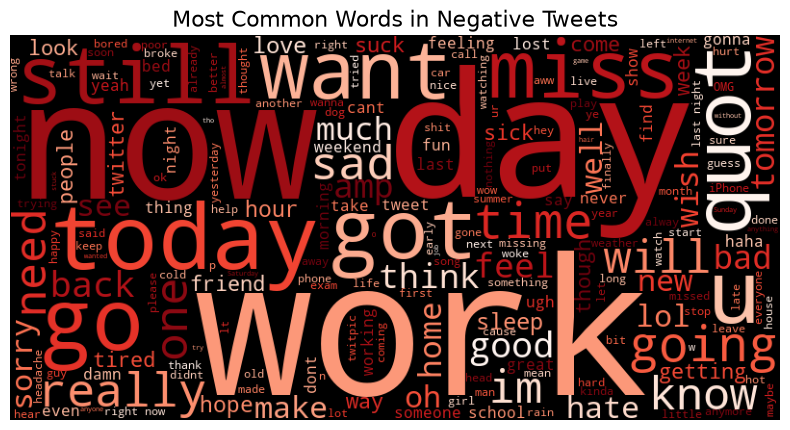

In [3]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# WordCloud for POSITIVE tweets
positive_text = ' '.join(df[df['target']==1]['text'].sample(5000, random_state=42))
wc = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(12,5))
plt.imshow(wc)
plt.axis('off')
plt.title('Most Common Words in Positive Tweets', fontsize=16)
plt.show()

# WordCloud for NEGATIVE tweets
negative_text = ' '.join(df[df['target']==0]['text'].sample(5000, random_state=42))
wc = WordCloud(width=800, height=400, background_color='black',
               colormap='Reds').generate(negative_text)

plt.figure(figsize=(12,5))
plt.imshow(wc)
plt.axis('off')
plt.title('Most Common Words in Negative Tweets', fontsize=16)
plt.show()

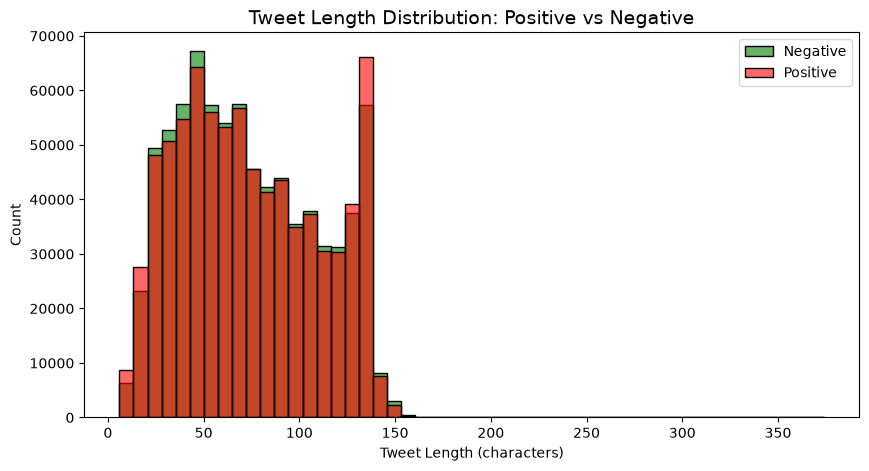

Average length - Positive tweets: 73.88
Average length - Negative tweets: 74.3


In [4]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='length', hue='target', bins=50, 
             palette={0:'red', 1:'green'}, alpha=0.6)
plt.title('Tweet Length Distribution: Positive vs Negative', fontsize=14)
plt.xlabel('Tweet Length (characters)')
plt.ylabel('Count')
plt.legend(labels=['Negative', 'Positive'])
plt.show()

print("Average length - Positive tweets:", df[df['target']==1]['length'].mean().round(2))
print("Average length - Negative tweets:", df[df['target']==0]['length'].mean().round(2))